# Titanic Survival Prediction
This notebook demonstrates a machine learning pipeline to predict passenger survival using Naive Bayes and SVM models.

In [172]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


## 1. Data Loading and Exploration

In [173]:
import pandas as pd
df = pd.read_csv("/kaggle/input/titanic-dataset/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [174]:
df.shape

(891, 12)

In [175]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [176]:
df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)

In [177]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 2. Feature Engineering & Preprocessing
In this section, we encode categorical variables and scale numerical features.

(array([30., 14., 10., 14.,  3., 29., 39., 65., 73., 42., 65., 62., 33.,
        47., 38., 21., 28., 21., 16., 14., 15.,  7.,  9.,  8.,  4.,  0.,
         5.,  1.,  0.,  1.]),
 array([ 0.42      ,  3.07266667,  5.72533333,  8.378     , 11.03066667,
        13.68333333, 16.336     , 18.98866667, 21.64133333, 24.294     ,
        26.94666667, 29.59933333, 32.252     , 34.90466667, 37.55733333,
        40.21      , 42.86266667, 45.51533333, 48.168     , 50.82066667,
        53.47333333, 56.126     , 58.77866667, 61.43133333, 64.084     ,
        66.73666667, 69.38933333, 72.042     , 74.69466667, 77.34733333,
        80.        ]),
 <BarContainer object of 30 artists>)

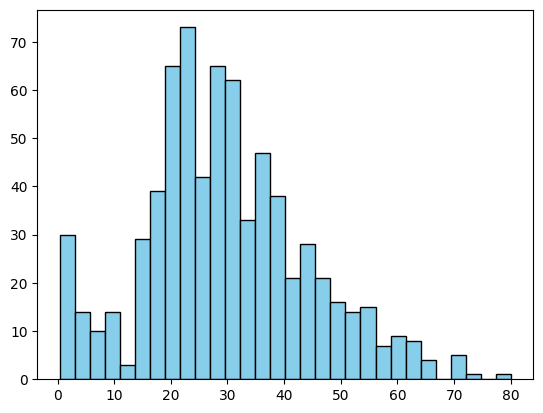

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.hist(df['Age'], bins=30, color='skyblue', edgecolor='black')

<Axes: ylabel='Age'>

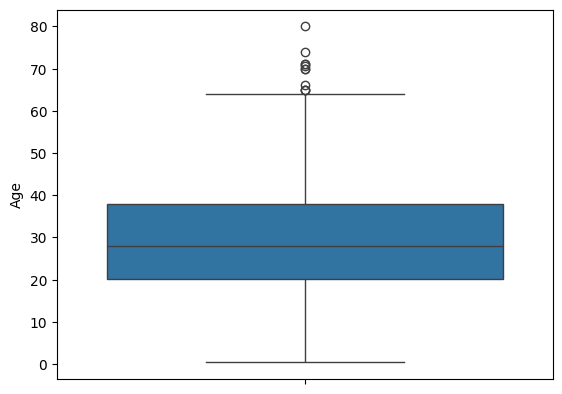

In [215]:
sns.boxplot(df['Age'])

In [179]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [180]:
df['Embarked'].nunique()

3

In [181]:
df['Embarked'] = le.fit_transform(df['Embarked'])

In [182]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [183]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
# df[['Age', 'Fare']] = sc.fit_transform(df[['Age', 'Fare']])

In [184]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [185]:
print(df.isna().sum())

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      0
dtype: int64


In [186]:
df.shape

(891, 8)

In [187]:
import numpy as np

In [188]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
# df['Age'] = imputer.fit_transform(df[['Age']])

In [189]:
print(df.isna().sum())

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      0
dtype: int64


In [190]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [191]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

In [192]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=67)
X_train[['Age', 'Fare']] = sc.fit_transform(X_train[['Age', 'Fare']])
X_test[['Age', 'Fare']] = sc.transform(X_test[['Age', 'Fare']])
X_train[['Age']] = imputer.fit_transform(X_train[['Age']])
X_test[['Age']] = imputer.transform(X_test[['Age']])

# 2. Using a dummy classifier

In [193]:
from sklearn.dummy import DummyClassifier

dcf = DummyClassifier(strategy="most_frequent")
dcf.fit(X_train, y_train)
y_pred = dcf.predict(X_test)

In [194]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.60


In [195]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[162   0]
 [106   0]]


In [196]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75       162
           1       0.00      0.00      0.00       106

    accuracy                           0.60       268
   macro avg       0.30      0.50      0.38       268
weighted avg       0.37      0.60      0.46       268



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [210]:
dcf2 = DummyClassifier(strategy="stratified")
dcf2.fit(X_train, y_train)
y_pred = dcf2.predict(X_test)

In [211]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.54


In [212]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[104  58]
 [ 66  40]]


In [213]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.64      0.63       162
           1       0.41      0.38      0.39       106

    accuracy                           0.54       268
   macro avg       0.51      0.51      0.51       268
weighted avg       0.53      0.54      0.53       268



## 3. Naive Bayes Classification
Training and evaluating a Gaussian Naive Bayes model.

In [197]:
X= df.drop('Survived',axis=1)
y= df['Survived']

In [198]:
bayes = GaussianNB()
bayes.fit(X_train,y_train)

GaussianNB()

In [199]:
y_pred = bayes.predict(X_test)

In [200]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [201]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.79


In [202]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[132  30]
 [ 26  80]]


In [203]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       162
           1       0.73      0.75      0.74       106

    accuracy                           0.79       268
   macro avg       0.78      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



## 4. Support Vector Machine (SVM) Classification
Comparing performance using an RBF kernel SVM.

In [204]:
from sklearn import svm

svm_model = svm.SVC(kernel='rbf', C=1.0, gamma='scale', random_state=67)

In [205]:
svm_model.fit(X_train, y_train)
predictions = svm_model.predict(X_test)

In [206]:
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.83


In [207]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))


Confusion Matrix:
[[145  17]
 [ 29  77]]


In [208]:
print("\nClassification Report:")
print(classification_report(y_test, predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       162
           1       0.82      0.73      0.77       106

    accuracy                           0.83       268
   macro avg       0.83      0.81      0.82       268
weighted avg       0.83      0.83      0.83       268

